# Exploratory Data Analysis

This notebook explores the MovieLens 100K dataset used in the recommendation system project.

The main goals are:

- understand the user, movie, and rating tables
- inspect interaction patterns
- check rating distribution
- explore temporal activity
- look at highly rated genre behavior

This analysis helps verify the data before training recommendation models.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data.download import download_movielens_100k
from src.data.preprocessing import load_movielens_data, clean_ratings, preprocess_tables

In [3]:
dataset_dir = download_movielens_100k()
users_df, ratings_df, items_df, genres_df = load_movielens_data(dataset_dir)

ratings_df = clean_ratings(ratings_df, items_df)
users_processed, items_processed = preprocess_tables(users_df, items_df)

## Raw table shapes

In [4]:
print("Users shape:", users_df.shape)
print("Ratings shape:", ratings_df.shape)
print("Items shape:", items_df.shape)

users_df.head()

Users shape: (943, 5)
Ratings shape: (99684, 6)
Items shape: (1681, 22)


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [5]:
ratings_df.head()

,user_id,movie_id,rating,timestamp,rating_timestamp,rating_month
0,259,255,4,874724710,1997-09-20 03:05:10,1997-09
1,259,286,4,874724727,1997-09-20 03:05:27,1997-09
2,259,298,4,874724754,1997-09-20 03:05:54,1997-09
3,259,185,4,874724781,1997-09-20 03:06:21,1997-09
4,259,173,4,874724843,1997-09-20 03:07:23,1997-09


In [6]:
items_df.head()

,movie_id,title,release_date,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,0,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


## Missing values

In [7]:
print("Users missing values:")
display(users_df.isna().sum())

print("\nRatings missing values:")
display(ratings_df.isna().sum())

print("\nItems missing values:")
display(items_df.isna().sum())

Users missing values:


user_id       0
age           0
gender        0
occupation    0
zip_code      0
dtype: int64


Ratings missing values:


user_id             0
movie_id            0
rating              0
timestamp           0
rating_timestamp    0
rating_month        0
dtype: int64


Items missing values:


movie_id        0
title           0
release_date    0
unknown         0
Action          0
Adventure       0
Animation       0
Children's      0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
dtype: int64

## Rating distribution

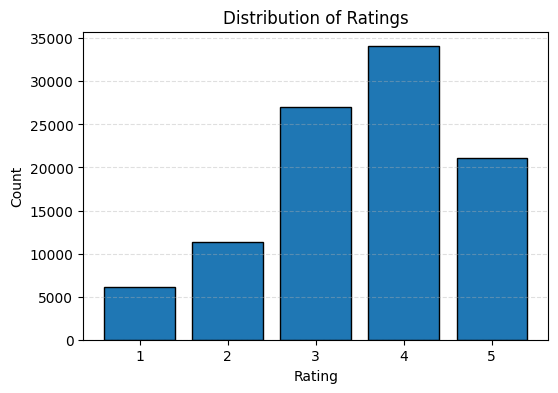

rating
1     6084
2    11336
3    27065
4    34059
5    21140
Name: count, dtype: int64

In [8]:
rating_counts = ratings_df["rating"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(rating_counts.index, rating_counts.values, edgecolor="black")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rating_counts.index)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

rating_counts

## Ratings over time

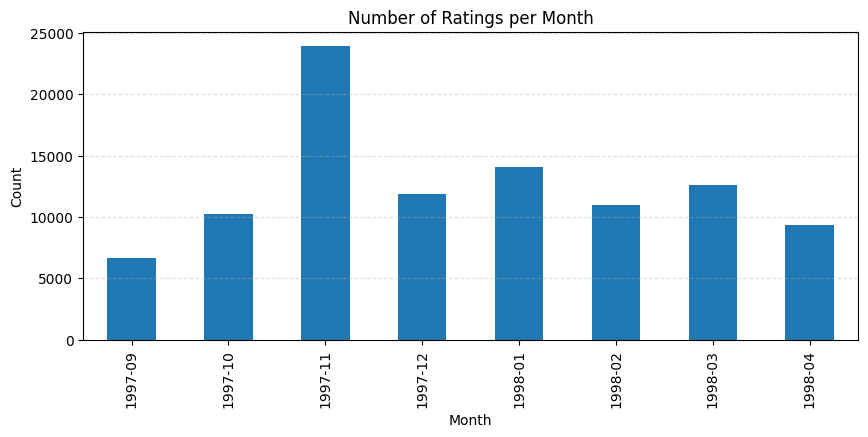

rating_month
1997-12    11871
1998-01    14052
1998-02    10950
1998-03    12618
1998-04     9325
Freq: M, Name: rating, dtype: int64

In [9]:
monthly_counts = ratings_df.groupby("rating_month")["rating"].count()

plt.figure(figsize=(10, 4))
monthly_counts.plot(kind="bar")
plt.title("Number of Ratings per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

monthly_counts.tail()

## Highly rated interactions
Here, highly rated means rating >= 4.

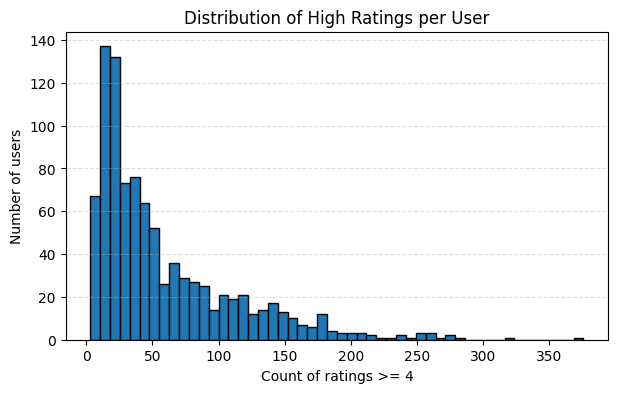

Average number of ratings >= 4 per user: 58.6


In [10]:
high_ratings = ratings_df[ratings_df["rating"] >= 4].copy()
high_rating_counts = high_ratings.groupby("user_id")["movie_id"].count()

plt.figure(figsize=(7, 4))
plt.hist(high_rating_counts, bins=50, edgecolor="black")
plt.title("Distribution of High Ratings per User")
plt.xlabel("Count of ratings >= 4")
plt.ylabel("Number of users")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

print("Average number of ratings >= 4 per user:", round(high_rating_counts.mean(), 2))

## Genre preference spread among users
This checks how many different genres appear in each user's highly rated movies.

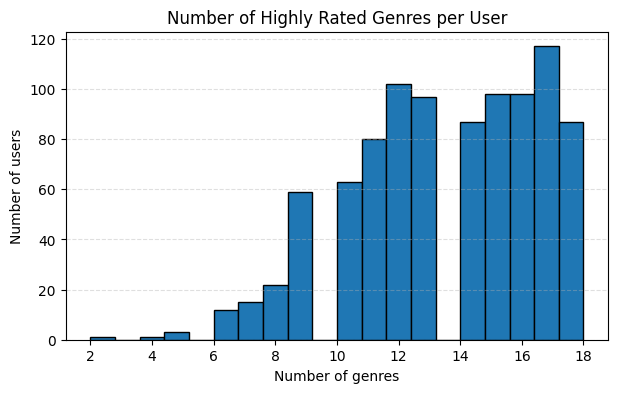

count    942.000000
mean      13.493631
std        3.123981
min        2.000000
25%       11.000000
50%       14.000000
75%       16.000000
max       18.000000
dtype: float64

In [11]:
high_ratings_with_items = high_ratings.merge(items_processed, on="movie_id")

genre_cols = [
    c for c in high_ratings_with_items.columns
    if c not in [
        "user_id", "movie_id", "rating", "timestamp",
        "rating_timestamp", "rating_month", "release_date", "title"
    ]
]

user_genre_counts = high_ratings_with_items.groupby("user_id")[genre_cols].max().sum(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(user_genre_counts, bins=20, edgecolor="black")
plt.title("Number of Highly Rated Genres per User")
plt.xlabel("Number of genres")
plt.ylabel("Number of users")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

user_genre_counts.describe()

## Basic observations

Some quick observations from the dataset:

- ratings are concentrated around the middle-to-high values
- user activity is uneven
- some users rate many more items than others
- temporal behavior matters, so a random split would be weaker than a time-based split
- users often highly rate movies across multiple genres, which supports trying both collaborative and feature-based approaches